# Feedforward Neural Network — Regression & Classification

This notebook trains a **Feedforward Neural Network (FFNN)** on the pre-processed student performance dataset.

| Task | Target | Metric |
|------|--------|--------|
| Regression | `exam_score` | RMSE, MAE, R² |
| Classification | `dropout_risk` | Accuracy, F1, ROC-AUC |

Mirrors the structure of `decision_trees.ipynb` for easy side-by-side comparison.

---
## 1 · Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/ffnn'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Using device: cpu
Config OK. Output directory: ../project/outputs/ffnn


---
## 2 · Load Pre-Processed Artefacts

In [7]:
# # Feature matrices (scaled — essential for neural networks)
# X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
# X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
# X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)
#
# # Regression targets
# y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
# y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
# y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()
#
# # Classification targets
# y_clf_train = pd.read_csv(f'{PROCESSED_DIR}/y_clf_train.csv', index_col=0).squeeze()
# y_clf_val   = pd.read_csv(f'{PROCESSED_DIR}/y_clf_val.csv',   index_col=0).squeeze()
# y_clf_test  = pd.read_csv(f'{PROCESSED_DIR}/y_clf_test.csv',  index_col=0).squeeze()
#
# feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()
#
# print('Loaded splits:')
# for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
#     print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')
# print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')
# print(f'Classification target — class balance {y_clf_train.value_counts(normalize=True).round(3).to_dict()}')

## 2 · Load Pre-Processed Artefacts
# Feature matrices (scaled — essential for neural networks)
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv', index_col=0)
X_test = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv', index_col=0)

# 🔥 FIX: force numeric dtype (critical for PyTorch)
X_train = X_train.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_val = X_val.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_test = X_test.apply(pd.to_numeric, errors='coerce').astype(np.float32)

# Handle any NaNs introduced during coercion
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv', index_col=0).squeeze()
y_reg_test = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv', index_col=0).squeeze()

# Classification targets
y_clf_train = pd.read_csv(f'{PROCESSED_DIR}/y_clf_train.csv', index_col=0).squeeze()
y_clf_val = pd.read_csv(f'{PROCESSED_DIR}/y_clf_val.csv', index_col=0).squeeze()
y_clf_test = pd.read_csv(f'{PROCESSED_DIR}/y_clf_test.csv', index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')

# 🔍 Sanity checks (VERY useful)
print('\nDtype check:', X_train.values.dtype)
print('NaNs in train:', np.isnan(X_train.values).sum())

print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')
print(
    f'Classification target — class balance {y_clf_train.value_counts(normalize=True).round(3).to_dict()}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Dtype check: float32
NaNs in train: 0

Regression target  — mean=89.15, std=11.57
Classification target — class balance {0.0: 0.981, 1.0: 0.019}


---
## 3 · Helper: Convert to PyTorch Tensors & DataLoaders

In [8]:
def make_loader(X, y, batch_size=512, shuffle=True, task='regression'):
    """Convert pandas DataFrames/Series to a PyTorch DataLoader."""
    X_t = torch.tensor(X.values, dtype=torch.float32)
    if task == 'regression':
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    else:
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 512
INPUT_DIM  = X_train.shape[1]
print(f'Input dimension: {INPUT_DIM}')

Input dimension: 49


---
## 4 · FFNN Architecture

In [9]:
class FFNN(nn.Module):
    """
    Configurable Feedforward Neural Network.

    Architecture (default):
        Input → FC(256) → BN → ReLU → Dropout(0.3)
               → FC(128) → BN → ReLU → Dropout(0.3)
               → FC(64)  → BN → ReLU → Dropout(0.2)
               → FC(32)  → ReLU
               → FC(output_dim)

    For regression  : output_dim=1, no final activation.
    For classification: output_dim=1, Sigmoid applied in loss (BCEWithLogitsLoss).
    """
    def __init__(self, input_dim, hidden_dims=(256, 128, 64, 32),
                 dropout_rates=(0.3, 0.3, 0.2, 0.0), output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim, drop in zip(hidden_dims, dropout_rates):
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
            ]
            if drop > 0:
                layers.append(nn.Dropout(drop))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Quick sanity check
dummy = torch.randn(4, INPUT_DIM)
model_check = FFNN(INPUT_DIM)
print('Output shape:', model_check(dummy).shape)   # expect (4, 1)
total_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 1])
Trainable parameters: 57,025


---
## 5 · Training Utility

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=100, patience=10, task='regression'):
    """
    Generic training loop with early stopping.

    Returns
    -------
    history : dict with 'train_loss' and 'val_loss' lists.
    """
    model.to(DEVICE)
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        # ── Early stopping ──────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stop at epoch {epoch}  (best val loss={best_val_loss:.5f})')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:4d} | train={train_loss:.5f} | val={val_loss:.5f}')

    model.load_state_dict(best_state)
    return history


def plot_loss_curve(history, title, save_path):
    plt.figure(figsize=(9, 4))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'],   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

---
## 6 · Regression Task — Predict `exam_score`

### 6.1 · Hyperparameter Search (Hidden-dim variants)

In [11]:
reg_train_loader = make_loader(X_train, y_reg_train, BATCH_SIZE, shuffle=True,  task='regression')
reg_val_loader   = make_loader(X_val,   y_reg_val,   BATCH_SIZE, shuffle=False, task='regression')

configs = [
    {'hidden_dims': (128, 64, 32),       'lr': 1e-3, 'label': 'Shallow (128-64-32)'},
    {'hidden_dims': (256, 128, 64, 32),  'lr': 1e-3, 'label': 'Default (256-128-64-32)'},
    {'hidden_dims': (512, 256, 128, 64), 'lr': 5e-4, 'label': 'Wide (512-256-128-64)'},
]

results_search = []
for cfg in configs:
    print(f"\nTraining: {cfg['label']}")
    m = FFNN(INPUT_DIM, hidden_dims=cfg['hidden_dims'])
    opt = optim.Adam(m.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    h   = train_model(m, reg_train_loader, reg_val_loader,
                      nn.MSELoss(), opt, sch, epochs=150, patience=15)
    # Val RMSE
    m.eval()
    with torch.no_grad():
        preds = m(torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()
    val_rmse = np.sqrt(mean_squared_error(y_reg_val, preds))
    results_search.append({'label': cfg['label'], 'val_rmse': val_rmse, 'model': m, 'history': h})
    print(f'  Val RMSE: {val_rmse:.3f}')

best_reg_result = min(results_search, key=lambda x: x['val_rmse'])
print(f"\nBest config: {best_reg_result['label']}  (Val RMSE={best_reg_result['val_rmse']:.3f})")
ffnn_reg = best_reg_result['model']


Training: Shallow (128-64-32)
  Epoch   10 | train=279.24923 | val=111.94009
  Epoch   20 | train=106.65004 | val=22.36907
  Epoch   30 | train=95.86469 | val=21.11411
  Epoch   40 | train=92.57684 | val=19.73178
  Epoch   50 | train=91.69598 | val=20.43327
  Early stop at epoch 58  (best val loss=19.17560)
  Val RMSE: 4.379

Training: Default (256-128-64-32)
  Epoch   10 | train=317.47241 | val=219.47356
  Epoch   20 | train=21.37929 | val=18.41520
  Epoch   30 | train=19.68210 | val=17.88559
  Epoch   40 | train=19.07492 | val=17.91330
  Early stop at epoch 46  (best val loss=17.65146)
  Val RMSE: 4.201

Training: Wide (512-256-128-64)
  Epoch   10 | train=1322.94860 | val=1117.24097
  Epoch   20 | train=24.05207 | val=18.75734
  Epoch   30 | train=20.26527 | val=17.58722
  Epoch   40 | train=19.71321 | val=17.54009
  Epoch   50 | train=19.11012 | val=17.50194
  Epoch   60 | train=19.01387 | val=17.48240
  Epoch   70 | train=18.94817 | val=17.47805
  Early stop at epoch 76  (best va

### 6.2 · Training Loss Curve

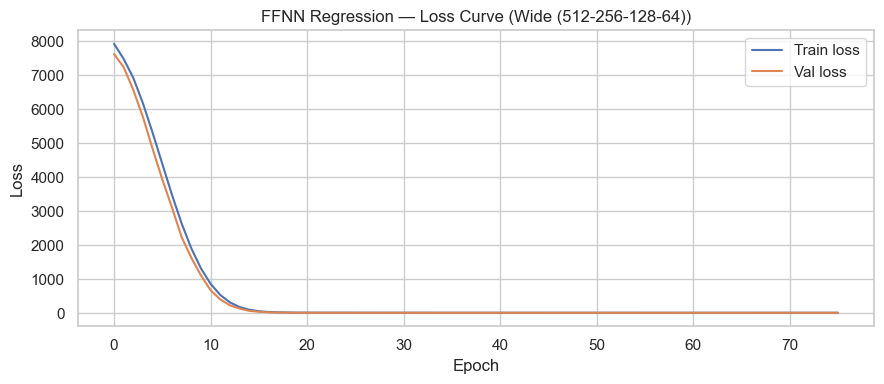

In [12]:
plot_loss_curve(
    best_reg_result['history'],
    f"FFNN Regression — Loss Curve ({best_reg_result['label']})",
    f'{OUT_DIR}/figures/reg_loss_curve.png'
)

### 6.3 · All Configs — Val RMSE Comparison

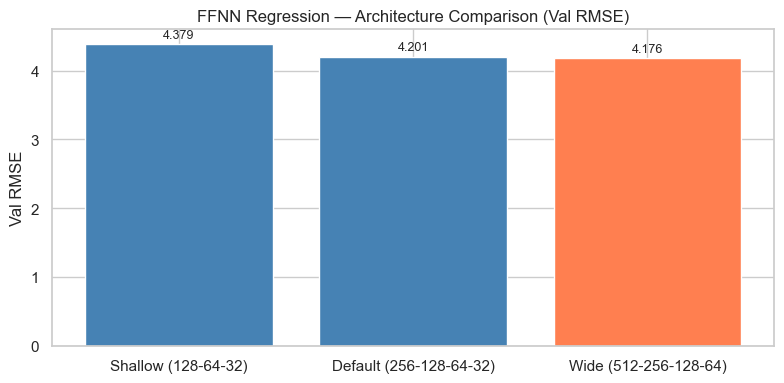

In [13]:
labels    = [r['label']    for r in results_search]
val_rmses = [r['val_rmse'] for r in results_search]

colors = ['steelblue' if l != best_reg_result['label'] else 'coral' for l in labels]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, val_rmses, color=colors)
plt.ylabel('Val RMSE')
plt.title('FFNN Regression — Architecture Comparison (Val RMSE)')
for bar, v in zip(bars, val_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_arch_comparison.png', dpi=150)
plt.show()

### 6.4 · Evaluate on Test Set

In [14]:
ffnn_reg.eval()
with torch.no_grad():
    y_reg_pred = ffnn_reg(
        torch.tensor(X_test.values, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  RMSE : {rmse:.3f}')
print(f'  MAE  : {mae:.3f}')
print(f'  R²   : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  RMSE : 4.109
  MAE  : 3.220
  R²   : 0.8781
───────────────────────────────────


### 6.5 · Actual vs Predicted Plot

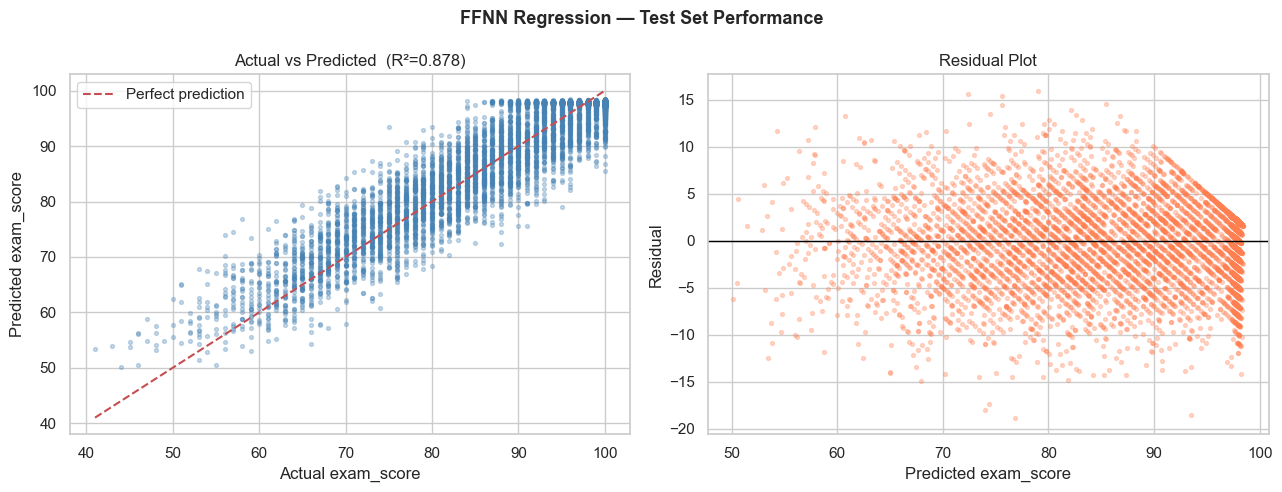

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('FFNN Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

### 6.6 · Feature Importances via Permutation

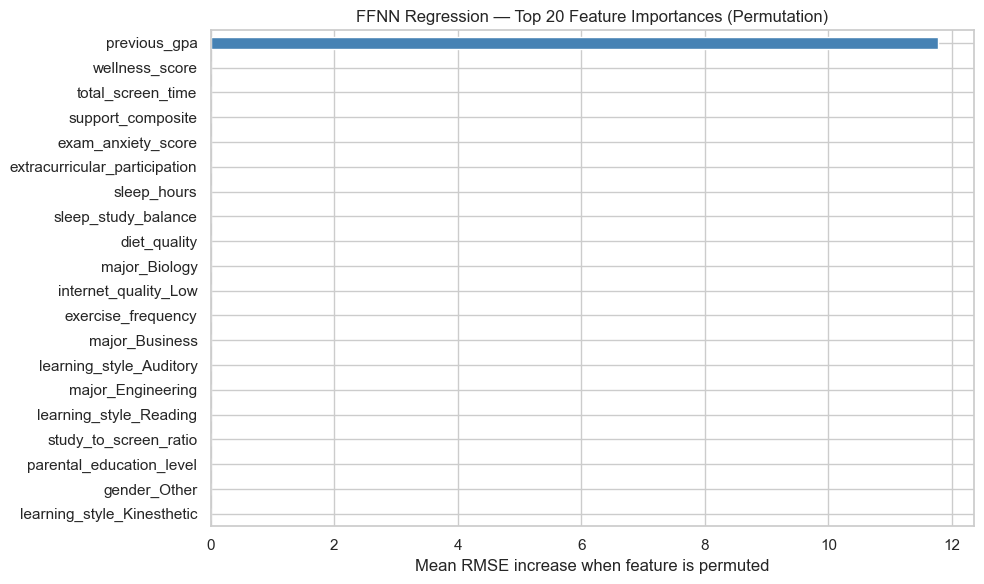

In [16]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

class FFNNSklearnWrapper(BaseEstimator, RegressorMixin):
    """Thin sklearn-compatible wrapper around our PyTorch FFNN."""
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()

wrapped = FFNNSklearnWrapper(ffnn_reg)
perm = permutation_importance(
    wrapped, X_test.values, y_reg_test.values,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)

importances = pd.Series(perm.importances_mean, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean RMSE increase when feature is permuted')
plt.title('FFNN Regression — Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

### 6.7 · Save Regression Model

In [17]:
torch.save(ffnn_reg.state_dict(), f'{OUT_DIR}/models/ffnn_reg.pt')
print('Regression FFNN saved.')

Regression FFNN saved.


---
## 7 · Classification Task — Predict `dropout_risk`

### 7.1 · Hyperparameter Search

In [18]:
clf_train_loader = make_loader(X_train, y_clf_train, BATCH_SIZE, shuffle=True,  task='clf')
clf_val_loader   = make_loader(X_val,   y_clf_val,   BATCH_SIZE, shuffle=False, task='clf')

clf_configs = [
    {'hidden_dims': (128, 64, 32),       'lr': 1e-3, 'label': 'Shallow (128-64-32)'},
    {'hidden_dims': (256, 128, 64, 32),  'lr': 1e-3, 'label': 'Default (256-128-64-32)'},
    {'hidden_dims': (512, 256, 128, 64), 'lr': 5e-4, 'label': 'Wide (512-256-128-64)'},
]

def val_auc(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()
        probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    return roc_auc_score(y_val, probs)

clf_results_search = []
for cfg in clf_configs:
    print(f"\nTraining: {cfg['label']}")
    m   = FFNN(INPUT_DIM, hidden_dims=cfg['hidden_dims'])
    opt = optim.Adam(m.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    h   = train_model(m, clf_train_loader, clf_val_loader,
                      nn.BCEWithLogitsLoss(), opt, sch, epochs=150, patience=15, task='clf')
    auc = val_auc(m, X_val, y_clf_val)
    clf_results_search.append({'label': cfg['label'], 'val_auc': auc, 'model': m, 'history': h})
    print(f'  Val AUC: {auc:.4f}')

best_clf_result = max(clf_results_search, key=lambda x: x['val_auc'])
print(f"\nBest config: {best_clf_result['label']}  (Val AUC={best_clf_result['val_auc']:.4f})")
ffnn_clf = best_clf_result['model']


Training: Shallow (128-64-32)
  Epoch   10 | train=0.08491 | val=0.09459
  Epoch   20 | train=0.07928 | val=0.09578
  Early stop at epoch 27  (best val loss=0.09371)
  Val AUC: 0.8062

Training: Default (256-128-64-32)
  Epoch   10 | train=0.08019 | val=0.09466
  Epoch   20 | train=0.07418 | val=0.09800
  Early stop at epoch 22  (best val loss=0.09430)
  Val AUC: 0.8014

Training: Wide (512-256-128-64)
  Epoch   10 | train=0.07885 | val=0.09461
  Epoch   20 | train=0.06910 | val=0.10050
  Early stop at epoch 22  (best val loss=0.09421)
  Val AUC: 0.8019

Best config: Shallow (128-64-32)  (Val AUC=0.8062)


### 7.2 · Training Loss Curve

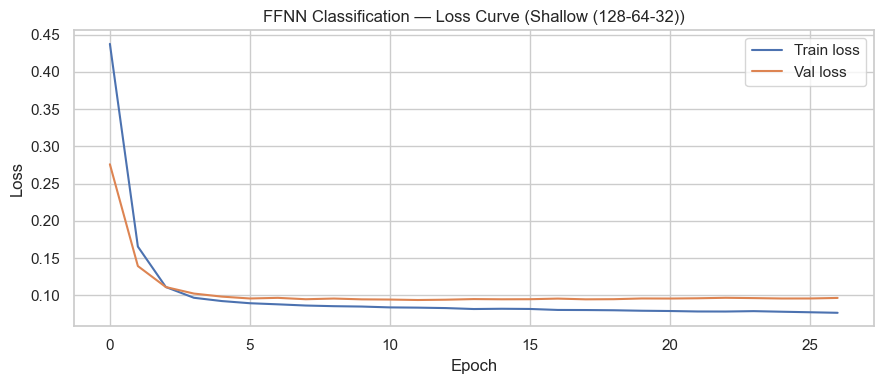

In [19]:
plot_loss_curve(
    best_clf_result['history'],
    f"FFNN Classification — Loss Curve ({best_clf_result['label']})",
    f'{OUT_DIR}/figures/clf_loss_curve.png'
)

### 7.3 · Evaluate on Test Set

In [20]:
ffnn_clf.eval()
with torch.no_grad():
    logits = ffnn_clf(
        torch.tensor(X_test.values, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy().flatten()

y_proba = torch.sigmoid(torch.tensor(logits)).numpy()
y_pred  = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_clf_test, y_pred)
f1  = f1_score(y_clf_test, y_pred)
auc = roc_auc_score(y_clf_test, y_proba)

print('─' * 35)
print(f'  Accuracy : {acc:.4f}')
print(f'  F1 Score : {f1:.4f}')
print(f'  ROC-AUC  : {auc:.4f}')
print('─' * 35)
print()
print(classification_report(y_clf_test, y_pred, target_names=['No Risk', 'Dropout Risk']))

───────────────────────────────────
  Accuracy : 0.9806
  F1 Score : 0.0000
  ROC-AUC  : 0.8132
───────────────────────────────────

              precision    recall  f1-score   support

     No Risk       0.98      1.00      0.99      7845
Dropout Risk       0.00      0.00      0.00       155

    accuracy                           0.98      8000
   macro avg       0.49      0.50      0.50      8000
weighted avg       0.96      0.98      0.97      8000



### 7.4 · Confusion Matrix

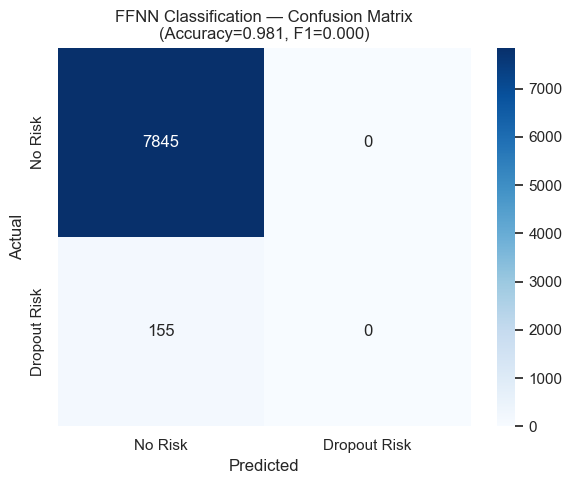

In [21]:
cm = confusion_matrix(y_clf_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk', 'Dropout Risk'],
            yticklabels=['No Risk', 'Dropout Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'FFNN Classification — Confusion Matrix\n(Accuracy={acc:.3f}, F1={f1:.3f})')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/clf_confusion_matrix.png', dpi=150)
plt.show()

### 7.5 · ROC Curve

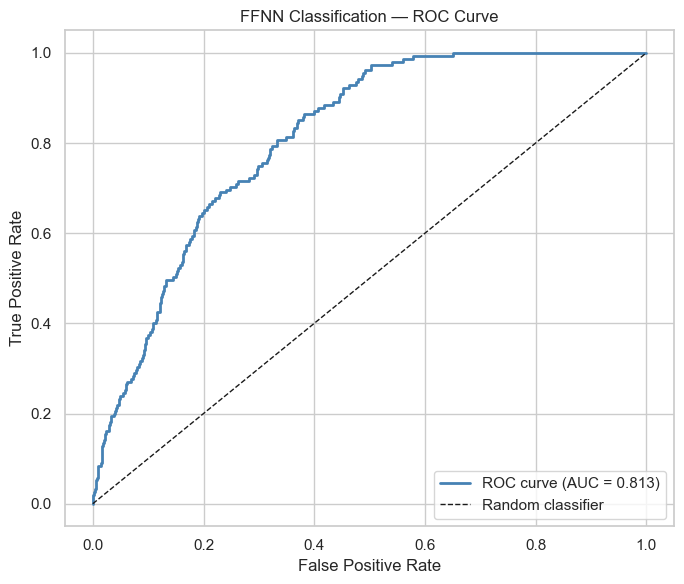

In [22]:
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN Classification — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/clf_roc_curve.png', dpi=150)
plt.show()

### 7.6 · Feature Importances via Permutation

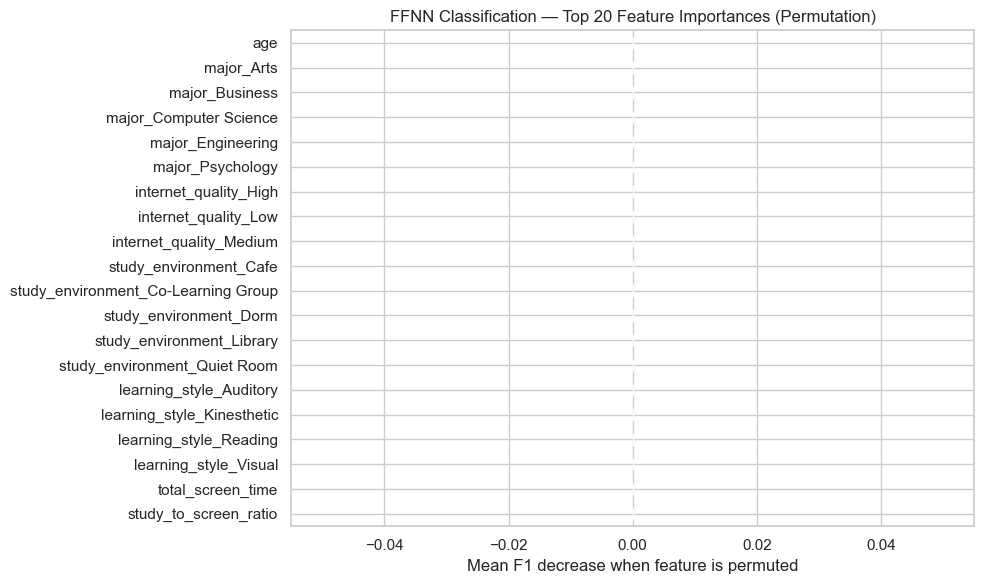

In [23]:
from sklearn.base import ClassifierMixin

class FFNNSklearnClfWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            logits = self.model(t).cpu().numpy().flatten()
        return (torch.sigmoid(torch.tensor(logits)).numpy() >= 0.5).astype(int)

wrapped_clf = FFNNSklearnClfWrapper(ffnn_clf)
perm_clf = permutation_importance(
    wrapped_clf, X_test.values, y_clf_test.values,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1'
)

clf_importances = pd.Series(perm_clf.importances_mean, index=feature_names)
top20_clf = clf_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20_clf.plot(kind='barh', color='mediumseagreen')
plt.gca().invert_yaxis()
plt.xlabel('Mean F1 decrease when feature is permuted')
plt.title('FFNN Classification — Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/clf_feature_importances.png', dpi=150)
plt.show()

### 7.7 · Save Classification Model

In [24]:
torch.save(ffnn_clf.state_dict(), f'{OUT_DIR}/models/ffnn_clf.pt')
print('Classification FFNN saved.')

Classification FFNN saved.


---
## 8 · Results Summary

In [25]:
summary = pd.DataFrame([
    {
        'Task':         'Regression (exam_score)',
        'Best Config':  best_reg_result['label'],
        'Test RMSE':    f'{rmse:.3f}',
        'Test MAE':     f'{mae:.3f}',
        'Test R²':      f'{r2:.4f}',
        'Test Acc':     '—',
        'Test F1':      '—',
        'Test AUC':     '—',
    },
    {
        'Task':         'Classification (dropout_risk)',
        'Best Config':  best_clf_result['label'],
        'Test RMSE':    '—',
        'Test MAE':     '—',
        'Test R²':      '—',
        'Test Acc':     f'{acc:.4f}',
        'Test F1':      f'{f1:.4f}',
        'Test AUC':     f'{auc:.4f}',
    },
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best Config,Test RMSE,Test MAE,Test R²,Test Acc,Test F1,Test AUC
0,Regression (exam_score),Wide (512-256-128-64),4.109,3.220,0.8781,—,—,—
1,Classification (dropout_risk),Shallow (128-64-32),—,—,—,0.9806,0.0000,0.8132



All figures saved to: ../project/outputs/ffnn/figures/
All models saved to:  ../project/outputs/ffnn/models/
